<a href="https://colab.research.google.com/github/jennygn/Ejercicios/blob/main/4-Ejercicios/04-kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/andres-merino/Curso-FundMachineLearning/blob/main/4-Ejercicios/04-kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i0.wp.com/see-ec.org/wordpress/wp-content/uploads/2023/01/LOGO-SEE-texto-blanco-3.png?w=1356&ssl=1" width="200">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#008dc3" size="7">|</font><br>
            <font color="#008dc3" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#008dc3" size="5">
                <b>Sociedad Ecuatoriana de Estadística</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#008dc3" size="4">
                Aprendizaje Automático Inicial &bull; Algoritmo k-Nearest Neighbors
            </font></p>
            <p style="font-style: oblique;"><font color="#008dc3" size="3">
                Andrés Merino &bull; 2025-04
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='008dc3'> Introducción </font>

A lo largo de este taller, aplicaremos el algoritmo de clasificación k-Nearest Neighbors (kNN) para predecir la clase de un conjunto de datos y también para predecir valores numéricos.

Los paquetes necesarios son:

In [6]:
# Paquetes necesariosimport pandas as pd  # Manejo de datos
import matplotlib.pyplot as plt  # Visualización

from sklearn.preprocessing import StandardScaler  # Estandarización de datos
from sklearn.datasets import make_blobs # Dataset
from sklearn.model_selection import train_test_split # División de datos
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Métrica de evaluación

# Algoritmo k-NN
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor


---
## <font color='008dc3'> Clasificación </font>


### <font color='008dc3'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase aterior.

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['cultivar'] = wine.target


print(df_wine.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  cultivar  
0        

In [ ]:
df_wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [ ]:
X = df_wine.drop('cultivar', axis=1)
y = df_wine['cultivar']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_wine.iloc[:, 1:-1])

df_wine_scaled = pd.DataFrame(X_scaled, columns=df_wine.columns[1:-1])
df_wine_scaled['cultivar'] = df_wine['cultivar']

print("Scaled DataFrame head:")
print(df_wine_scaled.head())

Scaled DataFrame head:
   malic_acid       ash  alcalinity_of_ash  magnesium  total_phenols  \
0   -0.562250  0.232053          -1.169593   1.913905       0.808997   
1   -0.499413 -0.827996          -2.490847   0.018145       0.568648   
2    0.021231  1.109334          -0.268738   0.088358       0.808997   
3   -0.346811  0.487926          -0.809251   0.930918       2.491446   
4    0.227694  1.840403           0.451946   1.281985       0.808997   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  \
0    1.034819             -0.659563         1.224884         0.251717   
1    0.733629             -0.820719        -0.544721        -0.293321   
2    1.215533             -0.498407         2.135968         0.269020   
3    1.466525             -0.981875         1.032155         1.186068   
4    0.663351              0.226796         0.401404        -0.319276   

        hue  od280/od315_of_diluted_wines   proline  cultivar  
0  0.362177                      1.847920


### <font color='008dc3'> Determinación del valor de k </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Determina el número óptimo de k para el algoritmo kNN:
<ul>
  <li>Genera una gráfica que muestre el valor de k vs la precisión del modelo.</li>
  <li>Selecciona el valor de k que maximice la precisión.</li>
</ul>
</div>


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

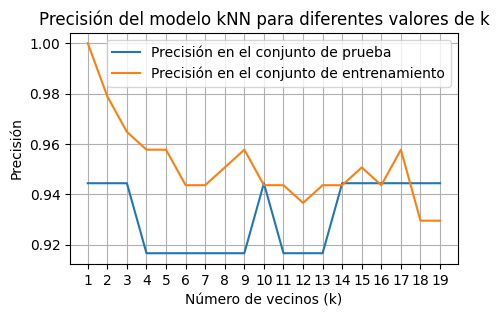

In [ ]:
accuracies = []
k_values = range(1, 20) # Probaremos k desde 1 hasta 19

precision_test = []
precision_train = []

for k in k_values:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train, y_train)
    y_pred_test = modelo.predict(X_test)
    y_pred_train = modelo.predict(X_train)
    precision_test.append(accuracy_score(y_test, y_pred_test))
    precision_train.append(accuracy_score(y_train, y_pred_train))



# Graficar k vs precisión
plt.figure(figsize=(5, 3))
plt.plot(k_values, precision_test, label='Precisión en el conjunto de prueba')
plt.plot(k_values, precision_train, label='Precisión en el conjunto de entrenamiento')
plt.title('Precisión del modelo kNN para diferentes valores de k')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Precisión')
plt.legend()
plt.xticks(k_values)
plt.grid(True)
plt.show()



### <font color='008dc3'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo con el valor de k seleccionado.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Genera una matriz de confusión y muestra las métricas de evaluación.</li>
</ul>
</div>

In [ ]:
# Realizamos el agrupamiento
modelo = KNeighborsClassifier(n_neighbors=10)
modelo.fit(X_train, y_train)

# Realizar predicciones y evaluar el modelo
y_pred = modelo.predict(X_test)

# Precisión del modelo con dos decimales
accuracy = round(accuracy_score(y_test, y_pred), 2)
print("Precisión del modelo:", accuracy)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

# Reporte de clasificación
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

Precisión del modelo: 0.94
Matriz de confusión:
[[14  0  0]
 [ 2 12  0]
 [ 0  0  8]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        14
           1       1.00      0.86      0.92        14
           2       1.00      1.00      1.00         8

    accuracy                           0.94        36
   macro avg       0.96      0.95      0.95        36
weighted avg       0.95      0.94      0.94        36



---
## <font color='008dc3'> Regresión </font>


### <font color='008dc3'> Preprocesamiento de datos </font>

Ejercicio:
Carga el conjunto de datos y procésalos:
Muestra algunos datos.
Muestra una descripción de los datos.
Escala los datos si es necesario.

In [12]:
from sklearn.datasets import load_diabetes


diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diabetes['target'] = diabetes.target


print("\nt5 primeras filas Diabetes dataset:")
print(df_diabetes.head())


print("\nDescripcion de Diabetes dataset:")
print(df_diabetes.describe())

X_reg = df_diabetes.drop('target', axis=1)
y_reg = df_diabetes['target']


scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)


df_diabetes_scaled = pd.DataFrame(X_reg_scaled, columns=X_reg.columns)
df_diabetes_scaled['target'] = y_reg

print("\n5 primeras filas del scalado Diabetes dataset:")
print(df_diabetes_scaled.head())


t5 primeras filas Diabetes dataset:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Descripcion de Diabetes dataset:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381


### <font color='008dc3'> Determinación del valor de k </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Determina el número óptimo de k para el algoritmo kNN:
<ul>
  <li>Genera una gráfica que muestre el valor de k vs la precisión del modelo.</li>
  <li>Selecciona el valor de k que maximice la precisión.</li>
</ul>
</div>


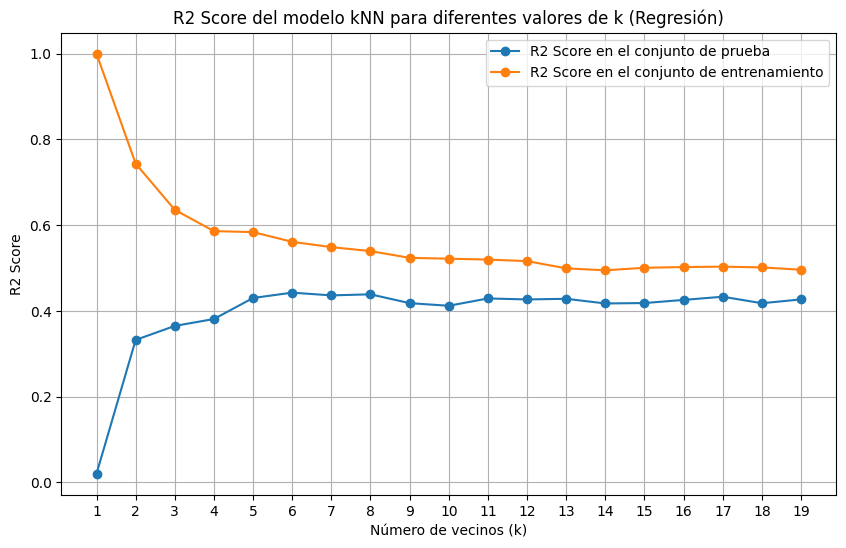

In [9]:

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

k_values_reg = range(1, 20) # Test k from 1 to 19

r2_test_reg = []
r2_train_reg = []

for k in k_values_reg:
    modelo_reg = KNeighborsRegressor(n_neighbors=k)
    modelo_reg.fit(X_train_reg, y_train_reg)
    y_pred_test_reg = modelo_reg.predict(X_test_reg)
    y_pred_train_reg = modelo_reg.predict(X_train_reg)
    r2_test_reg.append(r2_score(y_test_reg, y_pred_test_reg))
    r2_train_reg.append(r2_score(y_train_reg, y_pred_train_reg))

# Plot k vs R-squared score
plt.figure(figsize=(10, 6))
plt.plot(k_values_reg, r2_test_reg, label='R2 Score en el conjunto de prueba', marker='o')
plt.plot(k_values_reg, r2_train_reg, label='R2 Score en el conjunto de entrenamiento', marker='o')
plt.title('R2 Score del modelo kNN para diferentes valores de k (Regresión)')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('R2 Score')
plt.legend()
plt.xticks(k_values_reg)
plt.grid(True)
plt.show()


### <font color='008dc3'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo con el valor de k seleccionado.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Calcula el error cuadrático medio.</li>
</ul>
</div>

In [11]:
from sklearn.metrics import mean_squared_error


k_optimal_reg = 6


modelo_reg_final = KNeighborsRegressor(n_neighbors=k_optimal_reg)
modelo_reg_final.fit(X_train_reg, y_train_reg)

y_pred_reg = modelo_reg_final.predict(X_test_reg)


mse = mean_squared_error(y_test_reg, y_pred_reg)
print(f"Modelo kNN de Regresión con k={k_optimal_reg}:")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")


Modelo kNN de Regresión con k=6:
Error Cuadrático Medio (MSE): 2953.17
